# GraphSAGE / GNNExplainer – Global Feature Importance
This notebook aggregates feature attribution scores from GNNExplainer across cities and visualizes global importance patterns.

## 1. Imports

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Plot Settings

In [10]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2
})

## 3. Load and concatenate explainability results

In [11]:
FILES = [
    "../data/explainability/gnnexplainer/gnn_global_importance_atlanta.csv",
    "../data/explainability/gnnexplainer/gnn_global_importance_newyork.csv",
    "../data/explainability/gnnexplainer/gnn_global_importance_denver.csv",
    "../data/explainability/gnnexplainer/gnn_global_importance_boston.csv",
]

df = pd.concat([pd.read_csv(f) for f in FILES], ignore_index=True)

df.head()

,feature,importance,city
0,intersection_density,0.001792,atlanta
1,per_capita_income,0.001678,atlanta
2,street_density,0.001631,atlanta
3,pct_bachelors_degree,0.001514,atlanta
4,pct_car_commute,0.001475,atlanta


## 4. Compute global top features

In [12]:
top_features = (
    df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index
)

top_features.tolist()

['distance_to_cbd_km',
 'street_density',
 'pct_one_vehicle_households',
 'intersection_density',
 'poverty_rate',
 'pct_bachelors_degree',
 'avg_household_size',
 'public_assistance_rate',
 'pct_graduate_degree',
 'pct_car_commute',
 'per_capita_income',
 'pct_no_vehicle_households',
 'median_home_value',
 'node_density',
 'land_area_km2']

## 5. Pivot table for city comparison

In [13]:
plot_df = df[df["feature"].isin(top_features)].copy()

pivot = plot_df.pivot_table(
    index="feature",
    columns="city",
    values="importance",
    aggfunc="mean"
).loc[top_features]

## 6. City-wise comparison plot

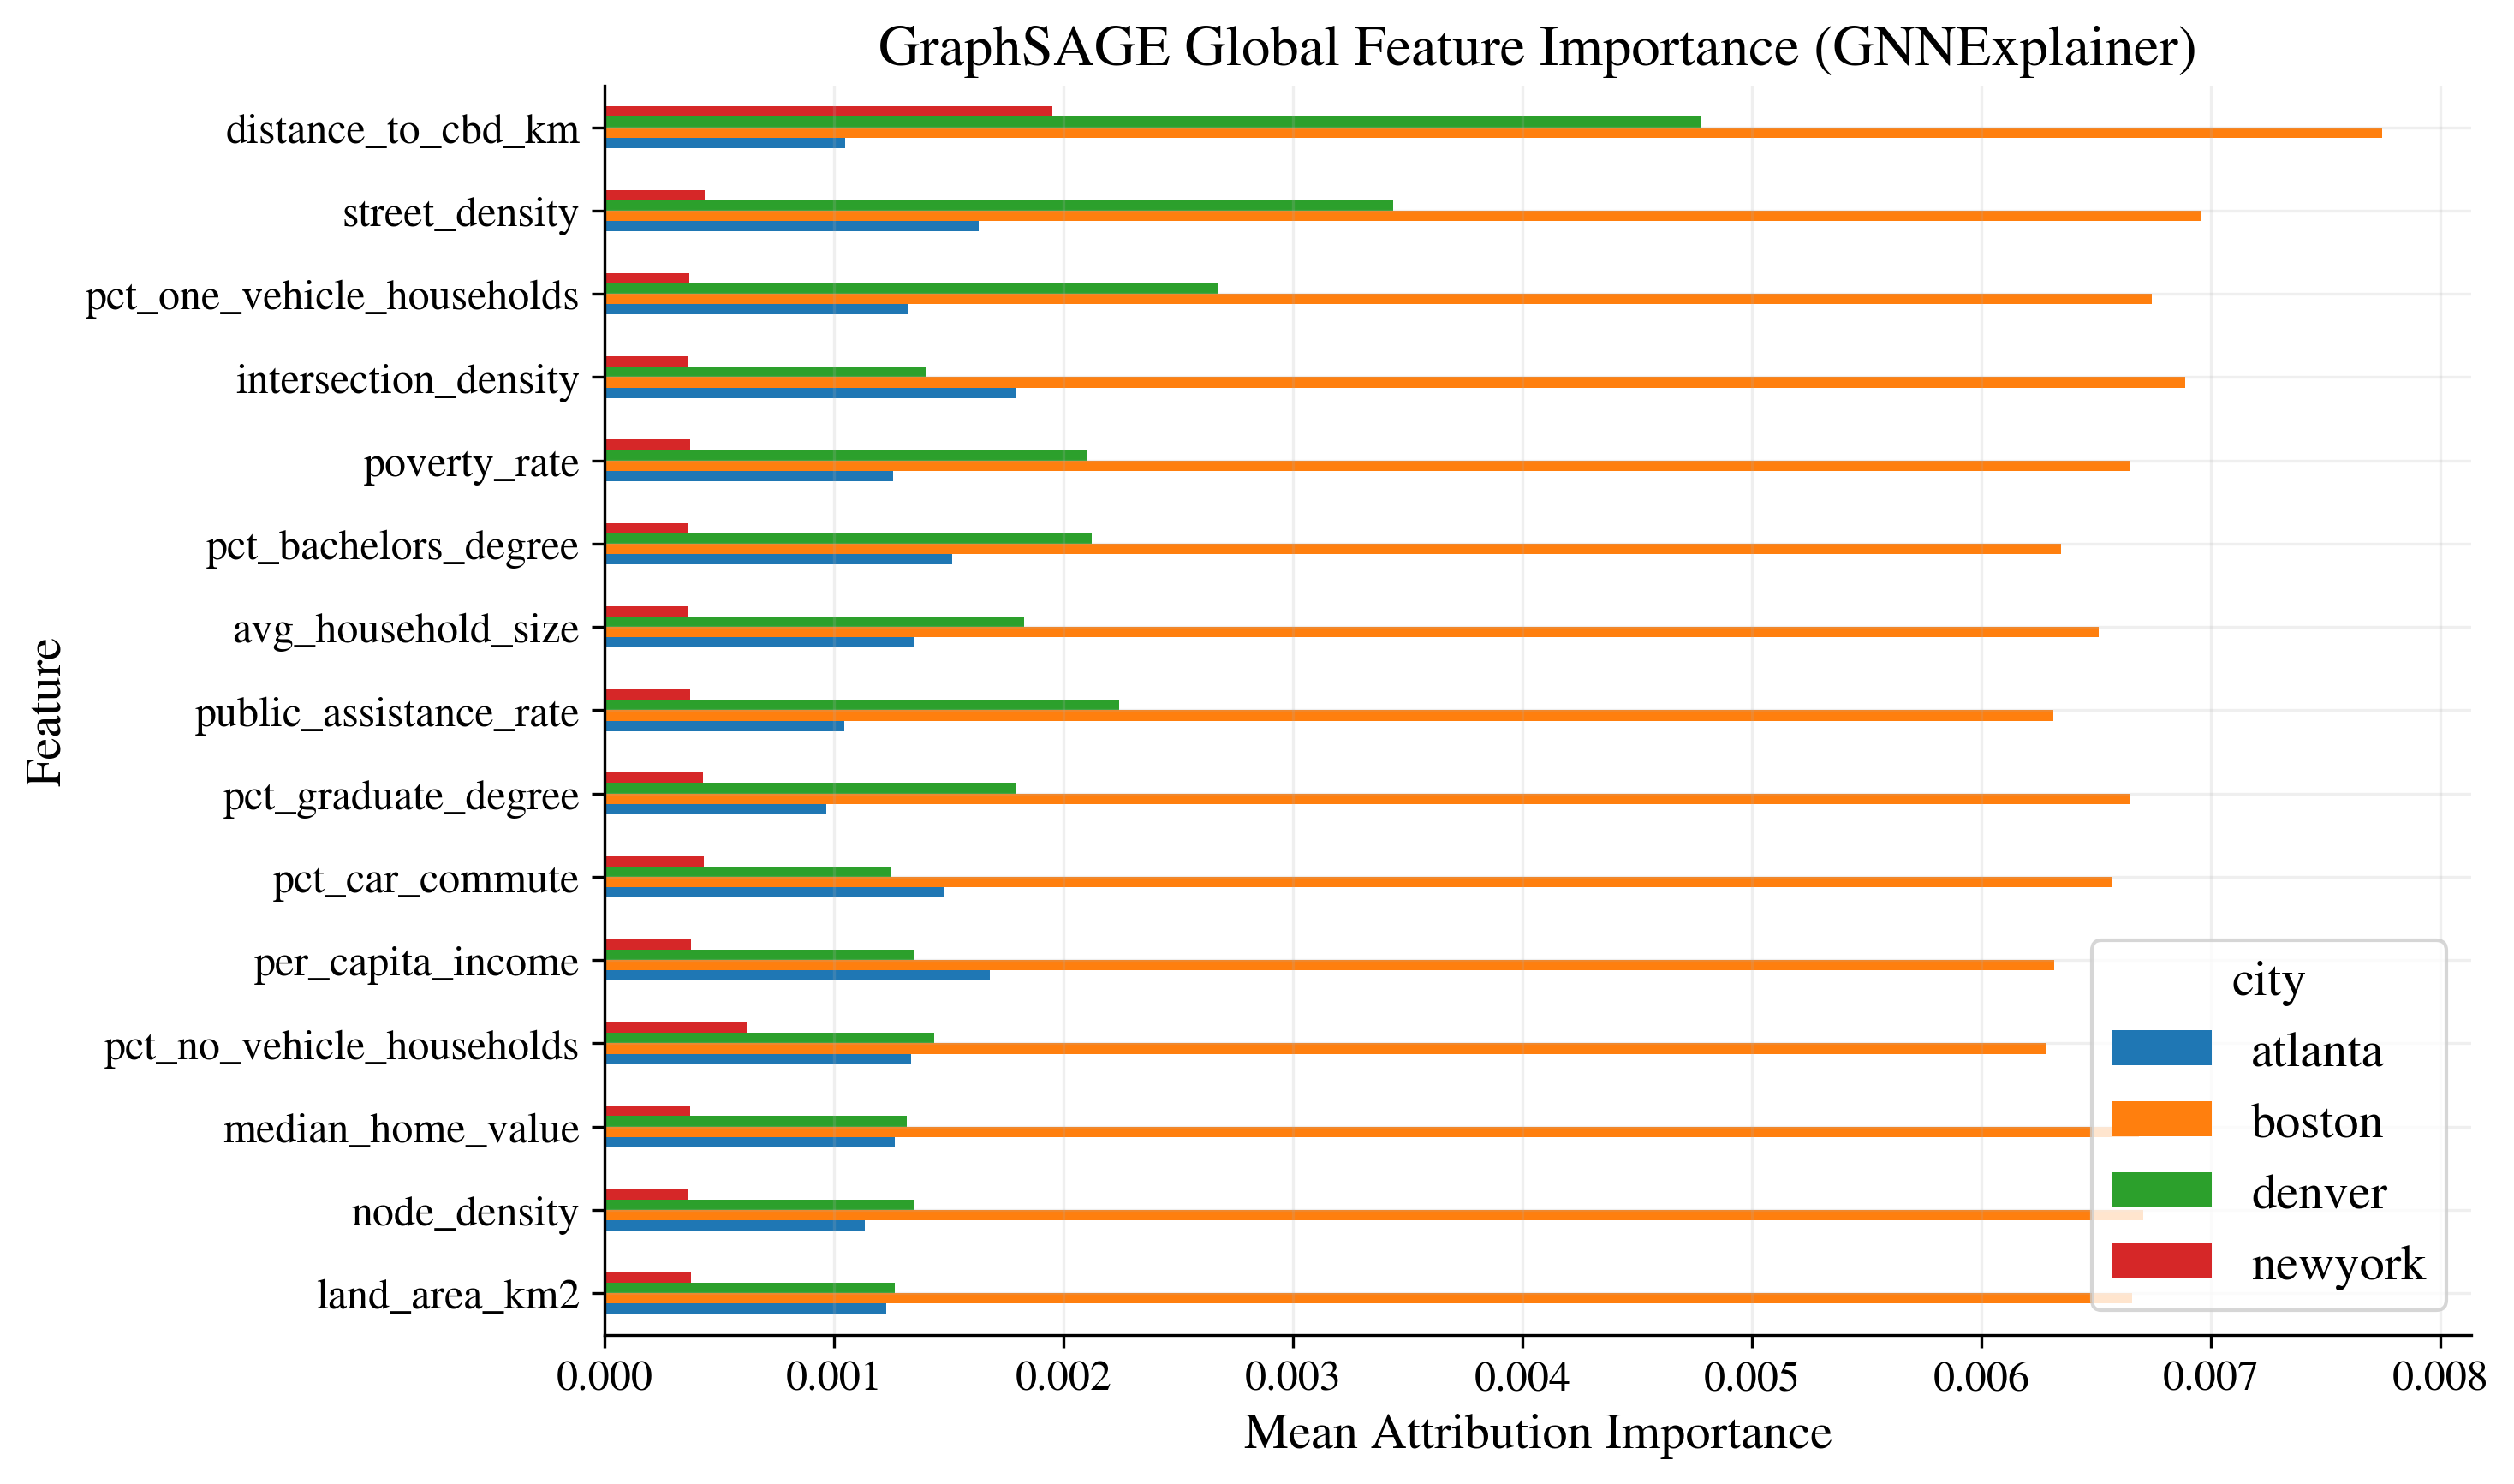

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

pivot.iloc[::-1].plot(
    kind="barh",
    ax=ax
)

ax.set_title("GraphSAGE Global Feature Importance (GNNExplainer)")
ax.set_xlabel("Mean Attribution Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## 7. Global mean importance (aggregated across cities)

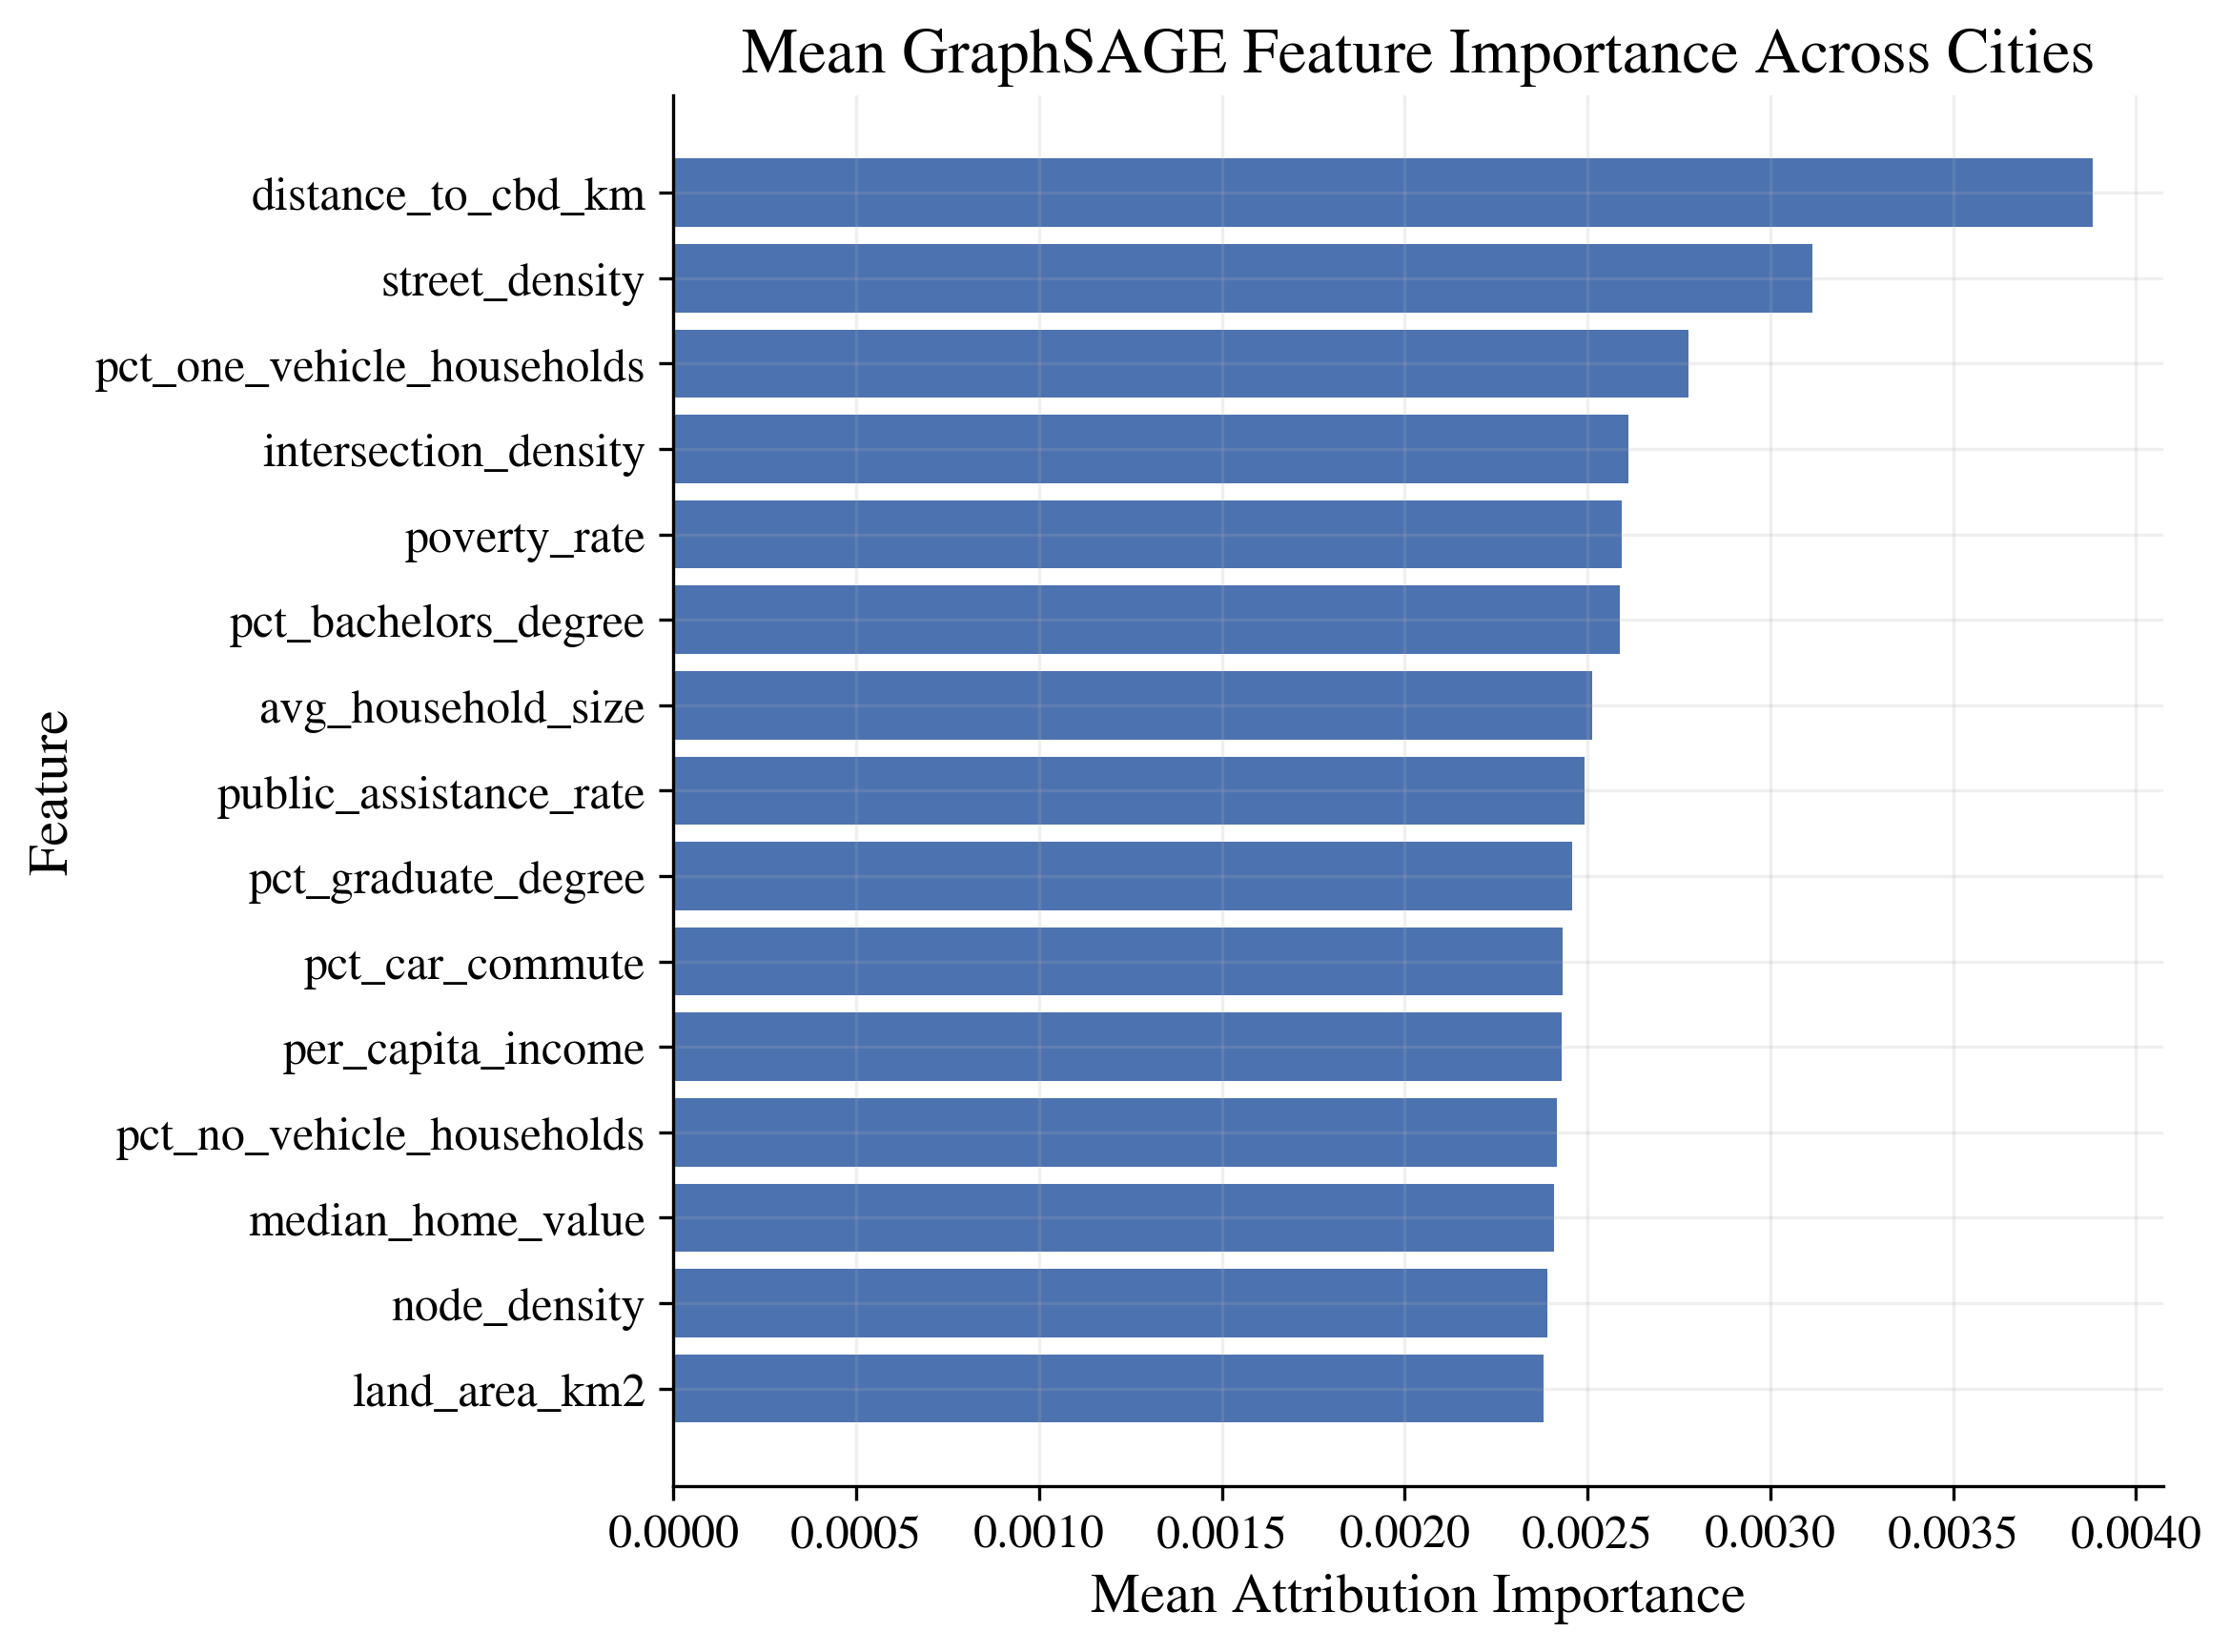

In [15]:
mean_importance = (
    df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.barh(
    mean_importance.index[::-1],
    mean_importance.values[::-1],
    color="#4C72B0"
)

ax.set_title("Mean GraphSAGE Feature Importance Across Cities")
ax.set_xlabel("Mean Attribution Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()